<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-5---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Entregable_Tarea_5_1_Alfaro_Cruz_Perez_Rupit_Medea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contaminación Atmosférica y Calidad del Aire (PM2.5)

## Exploración y Preprocesamiento
Rúbrica: 15% Manejo adecuado de valores nulos, codificación de categóricas y escalamiento de variables (crítico para GLM, $L_1$ / $L_2$ y Redes Neuronales).

## Resumen de la programación realizada en este código

1) Se sacaron los estadísticos
2) Creamos tres ejercicios de df imputados, el primero con medianas, el segundo con medias y el tercero con mice.  
3) Encontramos que: La información solo tenía datos con NA en la columna por modelar y representan menos del ¿4.7%? del total de datos, por lo que ...

In [ ]:
# Incluir librerías necesarias para procesamiento y graficación
import pandas as pd # Manejo de datos en tablas
import numpy as np # Operaciones numéricas
import matplotlib.pyplot as plt  # Gráficas
import seaborn as sns  # Gráficas más avanzadas
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.compose import ColumnTransformer

In [ ]:
# Importar la información
df = pd.read_csv("PRSA_data_2010.1.1-2014.12.31.csv")

In [ ]:
# Mostrar las primeras 5 filas
df.sample(10)

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
33861,33862,2013,11,11,21,81.0,-8,2.0,1025.0,SE,0.89,0,0
25708,25709,2012,12,7,4,61.0,-15,-10.0,1024.0,NW,23.69,0,0
12677,12678,2011,6,13,5,96.0,17,19.0,1007.0,cv,0.89,0,0
8986,8987,2011,1,10,10,NaN,-21,-5.0,1030.0,NE,4.92,0,0
16473,16474,2011,11,18,9,78.0,4,11.0,1015.0,NE,4.02,0,0
39438,39439,2014,7,2,6,59.0,20,21.0,1004.0,SE,0.89,0,0
1444,1445,2010,3,2,4,115.0,-6,-5.0,1018.0,cv,1.78,0,0
30424,30425,2013,6,21,16,67.0,17,29.0,1008.0,SE,28.16,0,0
18692,18693,2012,2,18,20,52.0,-20,-1.0,1027.0,NW,3.13,0,0
25941,25942,2012,12,16,21,138.0,-3,-2.0,1029.0,NE,1.79,0,0


# Glosario de Columnas Relevantes

pm2.5 --> PM25: Concentración de partículas PM2.5 (material particulado fino)

DEWP: Punto de rocío (Dew Point)

TEMP: Temperatura ambiente

PRES: Presión atmosférica

cbwd --> WIND_DIRECTION : Dirección combinada del viento

lws --> WIND_SPEED: velocidad acumulada del viento

ls: Horas acumuladas de nieve

lr: Horas acumuladas de lluvia

 -NW: Viento del noroeste

 -NE: Viento del noreste

 -SE: Viento del sureste

 -cv: Calm Variable (viento muy debil o dirección variable). *Combinación de las tres anteriores, sin rumbo fijo.

In [ ]:
# Revisar el tipos de datos y columnas presentes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  str    
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 4.3 MB


In [ ]:
#Renombrar encabezados
df = df.rename(columns={"No": "NO",
                        "year": "YEAR",
                        "month": "MONTH",
                        "day": "DAY",
                        "hour": "HOUR",
                        "pm2.5": "PM25",
                        "DEWP": "DEWPOINT",
                        "TEMP": "TEMP",
                        "PRES": "PRESION",
                        "cbwd": "WIND_DIRECTION",
                        "Iws": "WIND_SPEED",
                        "Is": "SNOW",
                        "Ir": "RAIN"})
df.info()  # Revisar el tipos de datos y columnas presentes

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NO              43824 non-null  int64  
 1   YEAR            43824 non-null  int64  
 2   MONTH           43824 non-null  int64  
 3   DAY             43824 non-null  int64  
 4   HOUR            43824 non-null  int64  
 5   PM25            41757 non-null  float64
 6   DEWPOINT        43824 non-null  int64  
 7   TEMP            43824 non-null  float64
 8   PRESION         43824 non-null  float64
 9   WIND_DIRECTION  43824 non-null  str    
 10  WIND_SPEED      43824 non-null  float64
 11  SNOW            43824 non-null  int64  
 12  RAIN            43824 non-null  int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 4.3 MB


In [ ]:
# Crear una columna con la fecha a partir de year, month, day y hour
# Mostrar resultados
df['FECHA'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY', 'HOUR']]) # Crea una columna con la fecha con hora
print("Rango de fechas del dataset:")
print(f"Desde: {df['FECHA'].min()} hasta {df['FECHA'].max()}")

# Observamos que las mediciones con cada hora
display(df["HOUR"].value_counts())

# Crear otra sin columna HOUR
df['FECHA_SIN_H'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']]) # Crea una columna con la fecha
print("Rango de fechas del dataset:")
print(f"Desde: {df['FECHA_SIN_H'].min()} hasta {df['FECHA_SIN_H'].max()}")

# Frecuencia de observaciones por día
display(df["FECHA"].value_counts())
display(df["FECHA_SIN_H"].value_counts())


Rango de fechas del dataset:
Desde: 2010-01-01 00:00:00 hasta 2014-12-31 23:00:00


HOUR
0     1826
1     1826
2     1826
3     1826
4     1826
5     1826
6     1826
7     1826
8     1826
9     1826
10    1826
11    1826
12    1826
13    1826
14    1826
15    1826
16    1826
17    1826
18    1826
19    1826
20    1826
21    1826
22    1826
23    1826
Name: count, dtype: int64

Rango de fechas del dataset:
Desde: 2010-01-01 00:00:00 hasta 2014-12-31 00:00:00


FECHA
2010-01-01 00:00:00    1
2010-01-01 01:00:00    1
2010-01-01 02:00:00    1
2010-01-01 03:00:00    1
2010-01-01 04:00:00    1
                      ..
2014-12-31 19:00:00    1
2014-12-31 20:00:00    1
2014-12-31 21:00:00    1
2014-12-31 22:00:00    1
2014-12-31 23:00:00    1
Name: count, Length: 43824, dtype: int64

FECHA_SIN_H
2010-01-01    24
2010-01-02    24
2010-01-03    24
2010-01-04    24
2010-01-05    24
              ..
2014-12-27    24
2014-12-28    24
2014-12-29    24
2014-12-30    24
2014-12-31    24
Name: count, Length: 1826, dtype: int64

In [ ]:
# Análisis de métricas principales de la información
df.drop(columns=["NO", "YEAR", "MONTH", "DAY", "HOUR"]).describe() # Estadísticas básicas sin considerar las fechas

,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,FECHA
count,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824
mean,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916,2012-07-01 23:30:00
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000,2010-01-01 00:00:00
25%,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000,2011-04-02 11:45:00
50%,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000,2012-07-01 23:30:00
75%,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000,2013-10-01 11:15:00
max,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000,2014-12-31 23:00:00
std,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867,NaN


Nota: El rango de las variables (diferente entre ellas) puede afectar el modelo por lo que es posible que se deba normalizar

In [ ]:
threshold = df['PM25'].quantile(0.99)
filtered_df = df[df['PM25'] >= threshold]
filtered_df['PM25'].describe()

count    423.000000
mean     493.101655
std       87.652354
min      420.000000
25%      439.000000
50%      470.000000
75%      508.000000
max      994.000000
Name: PM25, dtype: float64

En este bloque revisamos los outliers variando el percentil, no eliminamos dato.

In [ ]:
# Revisión de datos nulos de la información
df.isnull().sum()

NO                   0
YEAR                 0
MONTH                0
DAY                  0
HOUR                 0
PM25              2067
DEWPOINT             0
TEMP                 0
PRESION              0
WIND_DIRECTION       0
WIND_SPEED           0
SNOW                 0
RAIN                 0
FECHA                0
dtype: int64

In [ ]:
# Porcentaje de vacíos en la información por modelar
x = 2067/43824*100
print(round(x, 3), '%')

4.717 %


Sólo la variable por modelar tiene valores nulos y es menos del 4.72%

Text(0.5, 0, 'Concentración μg/m³')

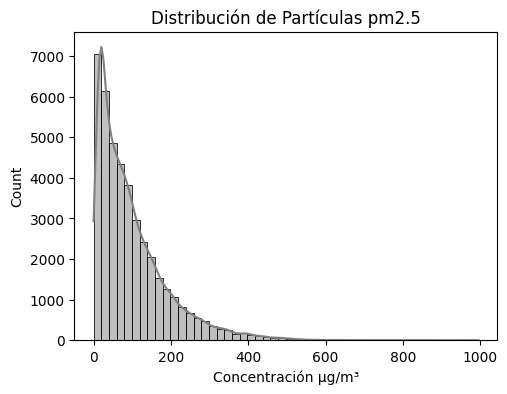

In [ ]:
# Configuración de los gráficos
plt.figure(figsize=(12, 4))

# 1. Gráfico para ver la distribución de pm2.5 e identificar sesgos o valores atípicos (outliers)
plt.subplot(1, 2, 1)
sns.histplot(df['PM25'].dropna(), bins=50, kde=True, color='grey')
plt.title('Distribución de Partículas pm2.5')
plt.xlabel('Concentración μg/m³')

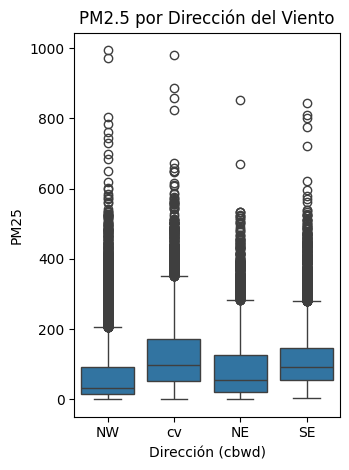

In [ ]:
# 2. Gráfico de caja para ver cómo afecta el viento en calma ('cv') frente a los otros a las PM2.5
plt.subplot(1, 2, 2)
sns.boxplot(x='WIND_DIRECTION', y='PM25', data=df)
plt.title('PM2.5 por Dirección del Viento')
plt.xlabel('Dirección (cbwd)')
plt.tight_layout()
plt.show()

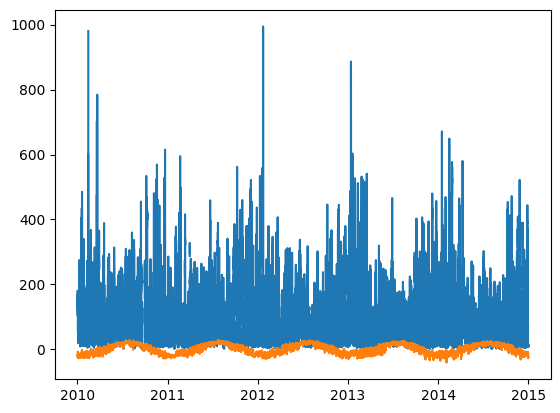

In [ ]:
plt.plot(df["FECHA"], df["PM25"], label="pm2.5")
plt.plot(df["FECHA"], df["DEWPOINT"], label="DEWP")

In [ ]:
# Rellenar nulos con la mediana
# df['pm2.5'] = df['pm2.5'].fillna(df['pm2.5'].median())

Opción 1: Eliminar nulos

Opción 2: Rellenar con la media

Opción 3: Rellenar con interpolación temporal

In [ ]:
# Limpio de NA
df_clean = df.dropna(subset=['PM25'])
print(len(df_clean))

41757


Agrego lo demas..

In [ ]:
print("Numero de filas del dataset: ", len(df))
print("")
df.describe()
df.info()
df.sample(10)
print("")
print(df[["SNOW", "RAIN"]].value_counts())

Numero de filas del dataset:  43824

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   NO              43824 non-null  int64         
 1   YEAR            43824 non-null  int64         
 2   MONTH           43824 non-null  int64         
 3   DAY             43824 non-null  int64         
 4   HOUR            43824 non-null  int64         
 5   PM25            41757 non-null  float64       
 6   DEWPOINT        43824 non-null  int64         
 7   TEMP            43824 non-null  float64       
 8   PRESION         43824 non-null  float64       
 9   WIND_DIRECTION  43824 non-null  str           
 10  WIND_SPEED      43824 non-null  float64       
 11  SNOW            43824 non-null  int64         
 12  RAIN            43824 non-null  int64         
 13  FECHA           43824 non-null  datetime64[us]
dtypes: datetime64[us](1), float6

In [ ]:
print(df.isna().sum())
print(" ")
print("Los valores de la unica columna tipo string (WIND_DIRECTION) son:")
print(df["WIND_DIRECTION"].value_counts())
print("Estos valores se les aplica One-hot encoding al ser muy pocas las categorias")

NO                   0
YEAR                 0
MONTH                0
DAY                  0
HOUR                 0
PM25              2067
DEWPOINT             0
TEMP                 0
PRESION              0
WIND_DIRECTION       0
WIND_SPEED           0
SNOW                 0
RAIN                 0
FECHA                0
dtype: int64
 
Los valores de la unica columna tipo string (WIND_DIRECTION) son:
WIND_DIRECTION
SE    15290
NW    14150
cv     9387
NE     4997
Name: count, dtype: int64
Estos valores se les aplica One-hot encoding al ser muy pocas las categorias


In [ ]:
# Dropping Data. Nueva dataset que elimina las files con NAs solo de la columna de pm2.5.

df_clean = df.dropna(subset="PM25")
df_clean.isna().sum()
len(df_clean)

# Impute data. Nuevo dataset imputado... Primero para decidir que tipo de Imputación realizar
# necesito saber que tan independientes o dependientes son mis variables entre si.
# Para ello necesito visualizar posibles correlaciones o relaciones estadisticas entre ellas.

# Dadas las graficas de abajo quiero diferenciar que variables son dependientes de otras, y ver como esto afecta al tipo de imputacion
# despues, normalizamos

41757

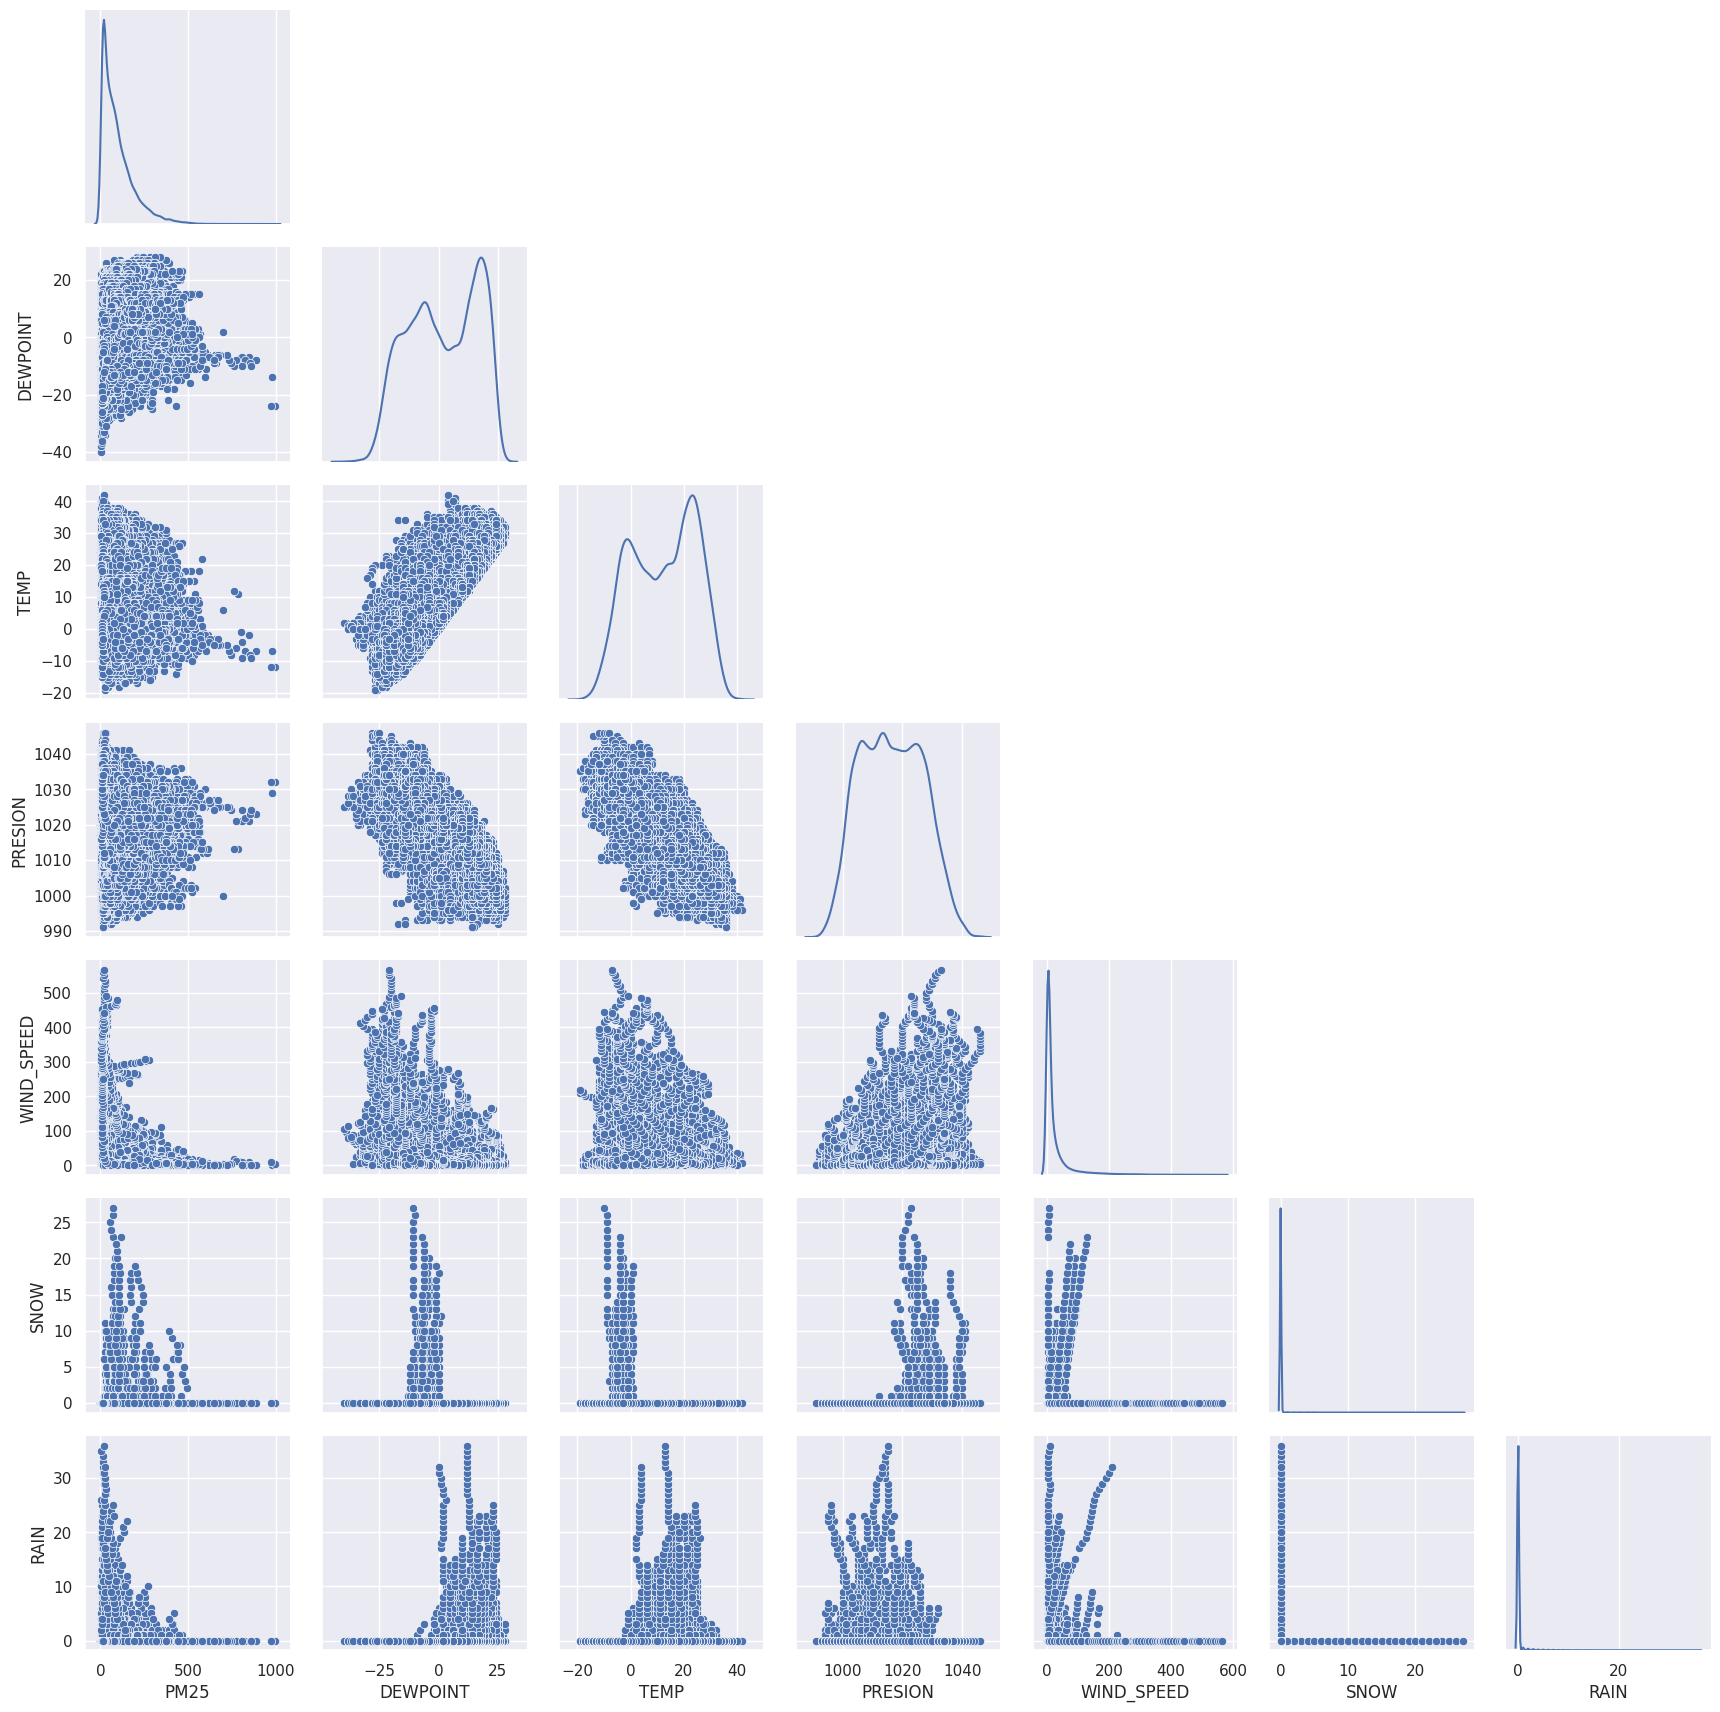

In [ ]:
g = sns.PairGrid(df_clean[["PM25", "DEWPOINT", "TEMP", "PRESION", "WIND_SPEED", "SNOW", "RAIN"]],
                 diag_sharey=False,
                 corner=True
                )
g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)
# llevar a la otra fase

In [ ]:
df["FECHA"].sample(3)


42766   2014-11-17 22:00:00
35325   2014-01-11 21:00:00
9945    2011-02-19 09:00:00
Name: FECHA, dtype: datetime64[us]

<function matplotlib.pyplot.show(close=None, block=None)>

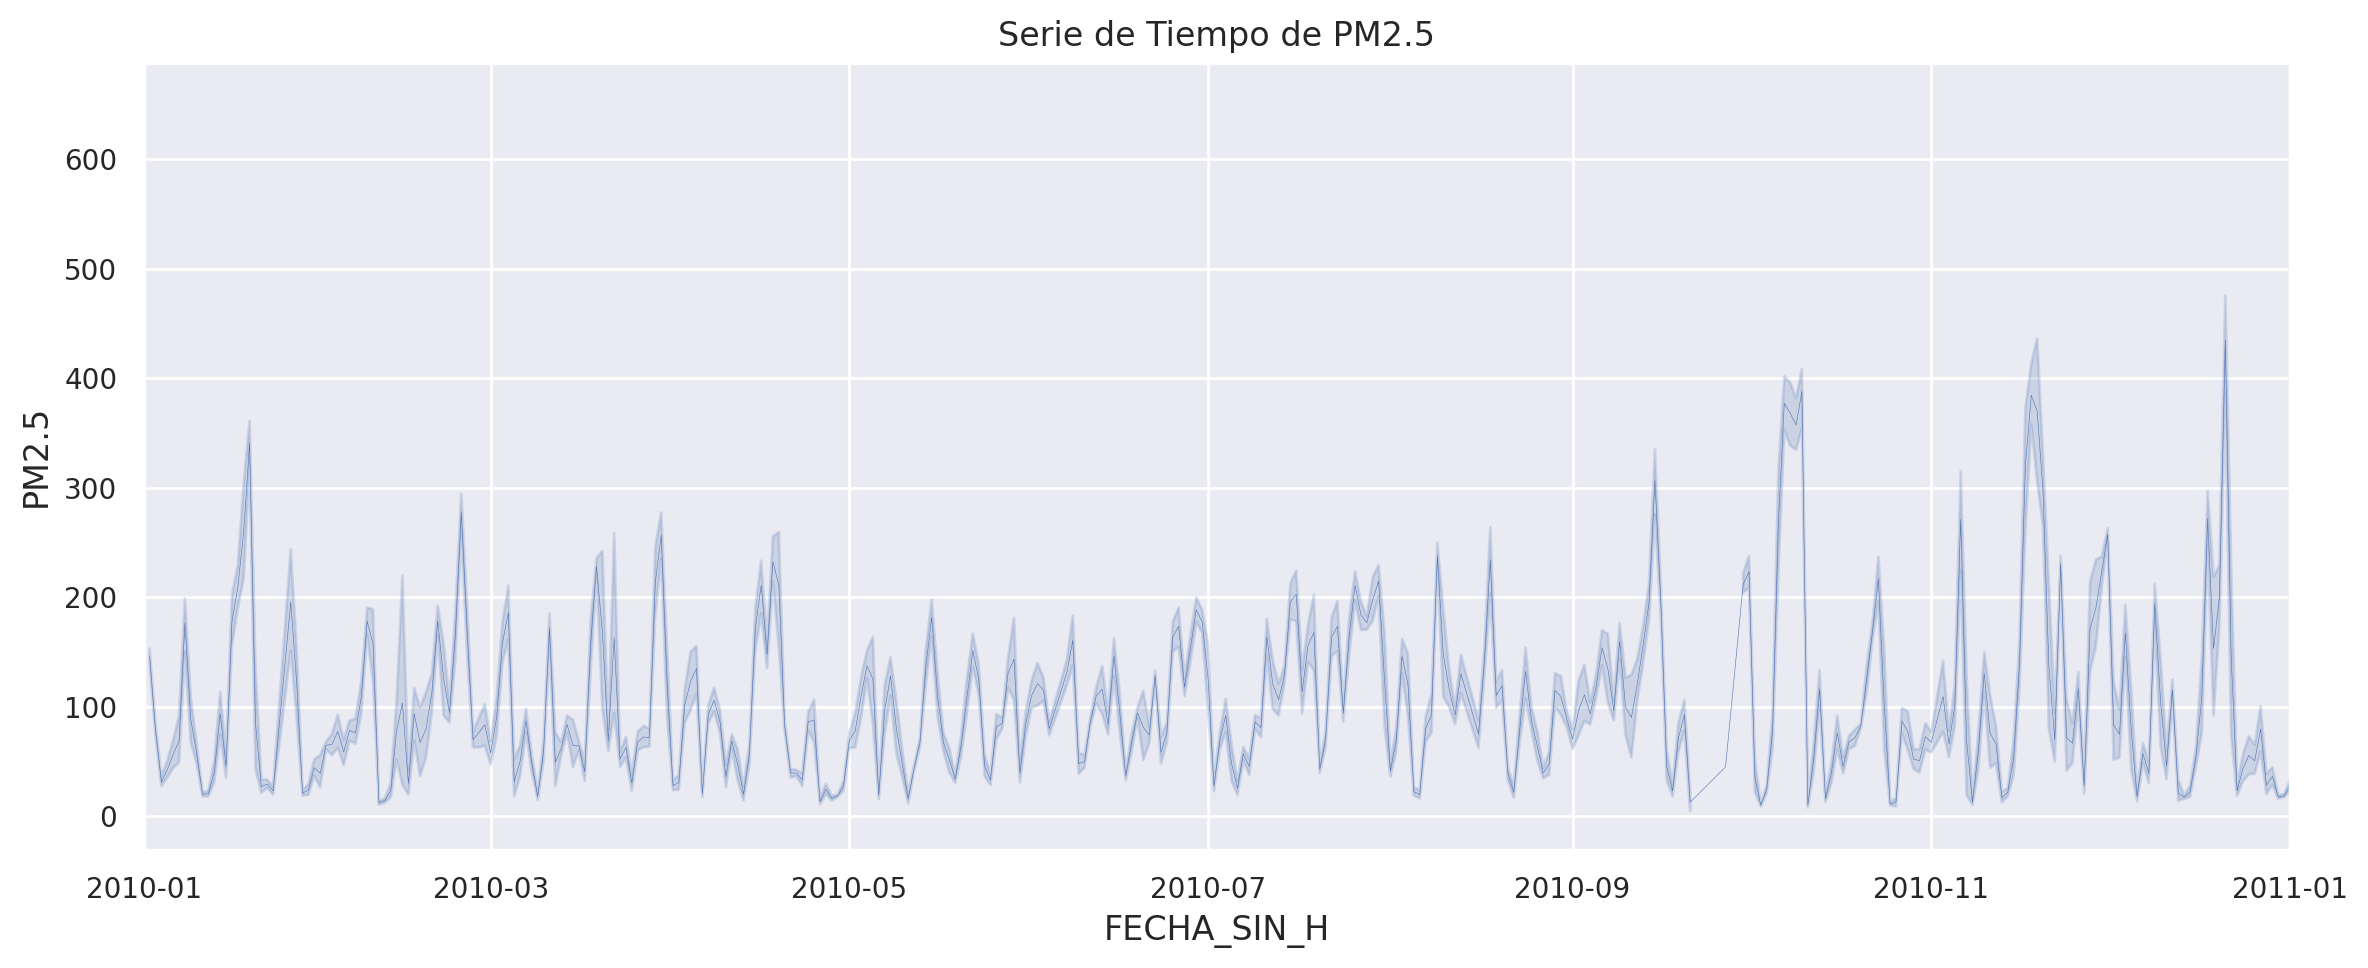

In [ ]:
# Time Series only for pm2.5 values

# Ojo!!! puede que nos este apilando los datos ya que tenemos mas de un dato por dia (dado la variable horas)

plt.rcParams["figure.dpi"] = 200
fig, ax = plt.subplots(figsize=(12,5))
sns.lineplot(x="FECHA_SIN_H", y="PM25",
             data=df,
             linewidth=0.2,
            )
ax.set(
    ylabel="PM2.5",
    title="Serie de Tiempo de PM2.5",
)
ax.tick_params(axis="both", labelsize=10)

plt.xlim(pd.Timestamp("2010-01-01"), pd.Timestamp("2011-01-01"))
plt.tight_layout()
plt.show

# Time Series por año
# Pendiente ver si sale...

<function matplotlib.pyplot.show(close=None, block=None)>

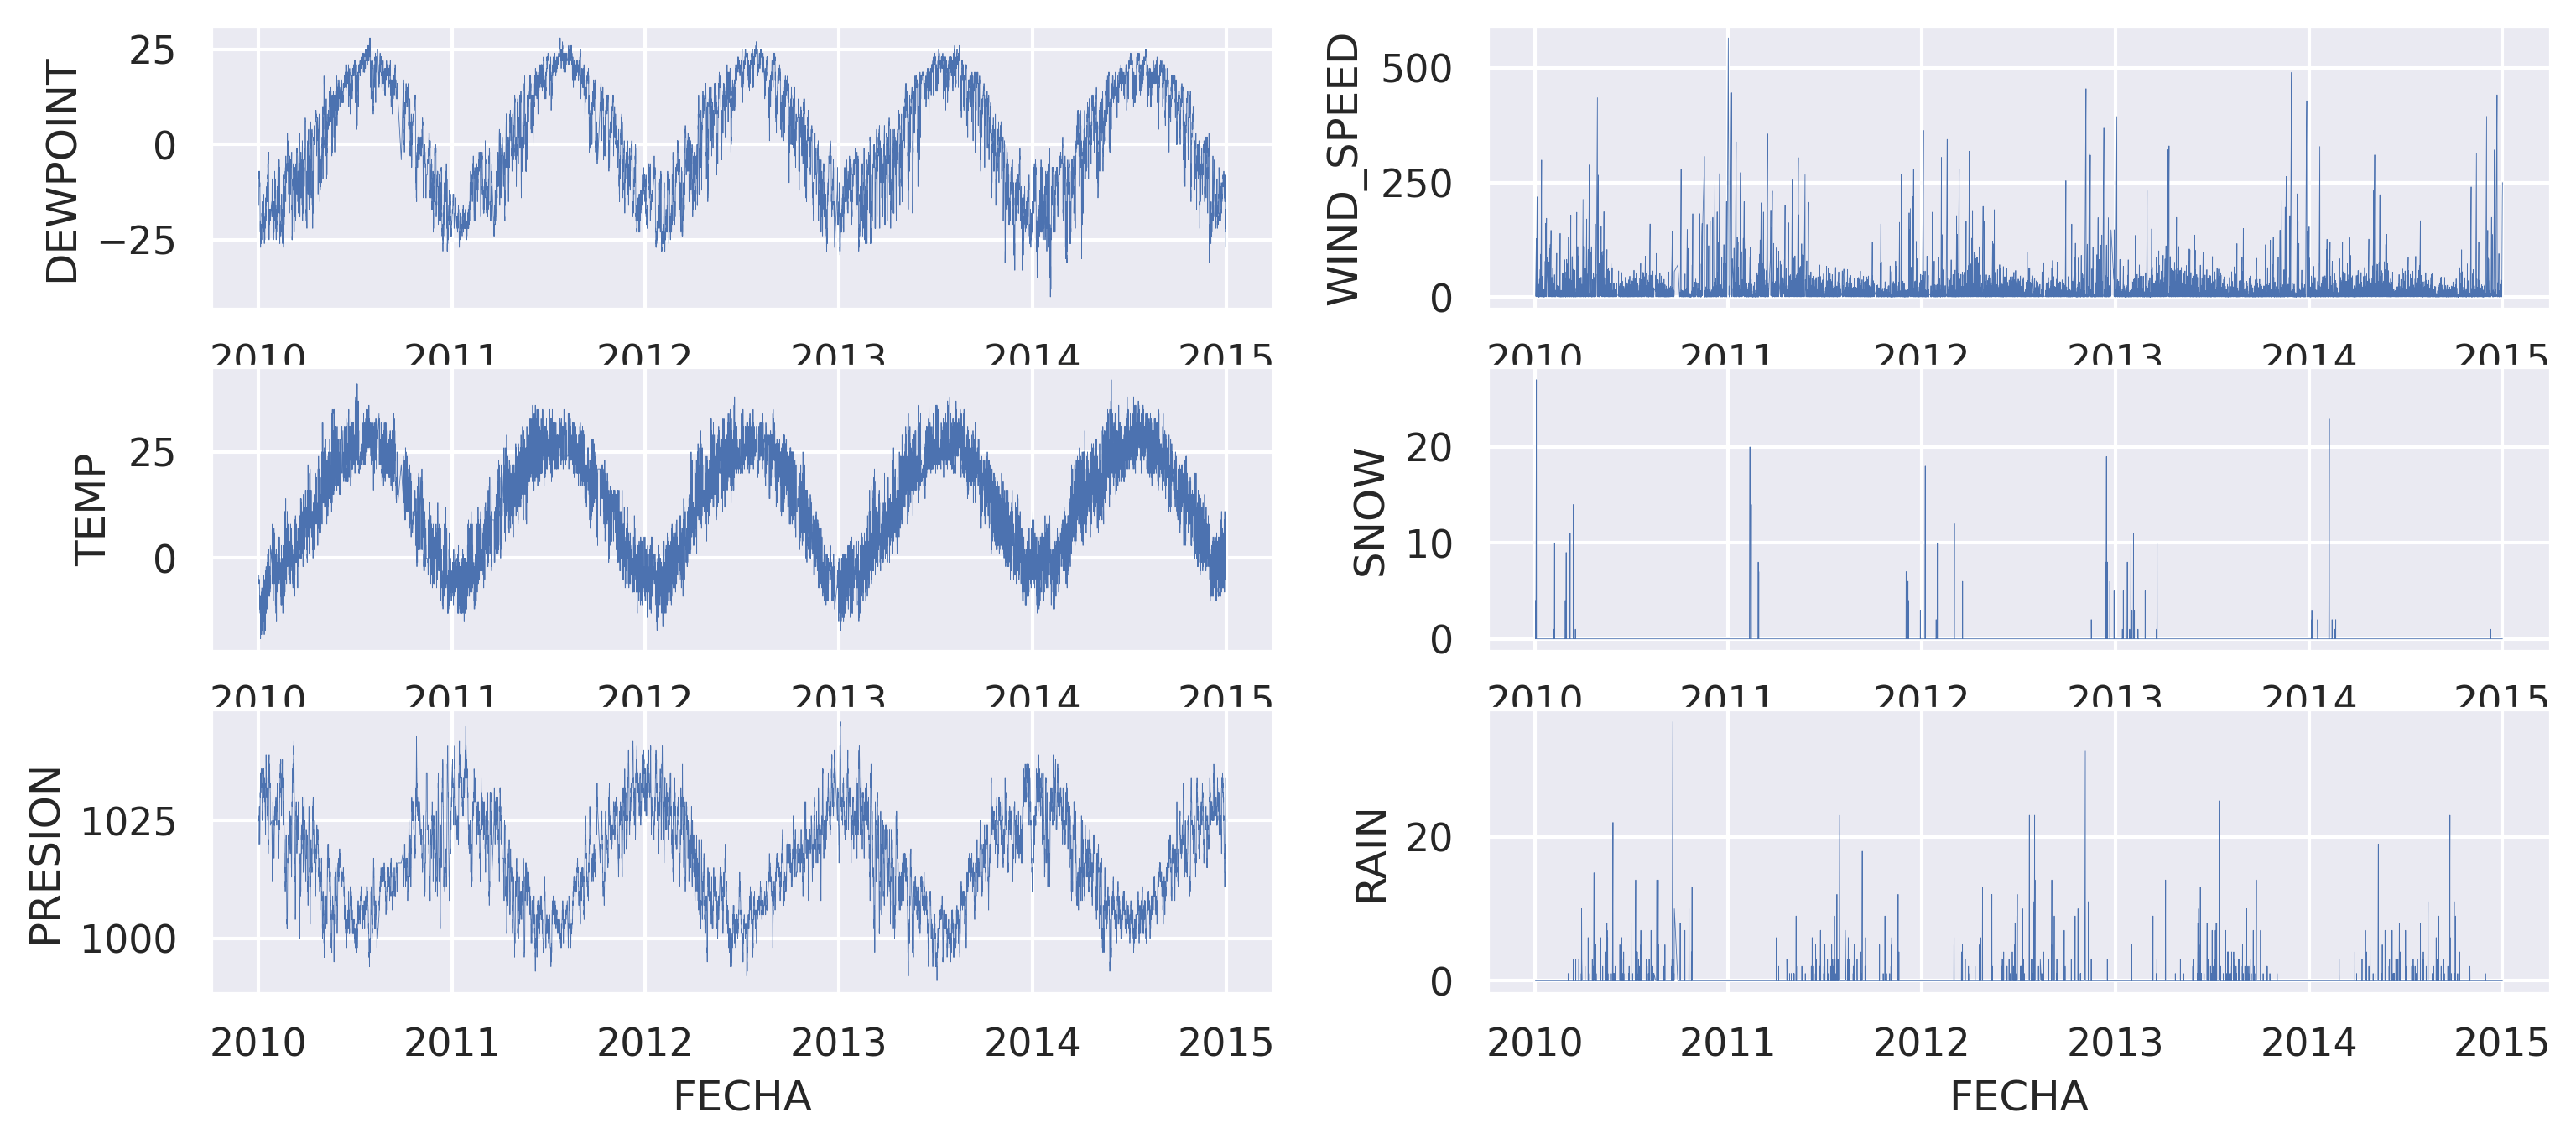

In [ ]:
# La recomendación de las series de tiempo (en un mismo figure)

plt.rcParams["figure.dpi"] = 300

fig, axs = plt.subplots(3,2, figsize=(12,5))
sns.lineplot(x="FECHA", y="DEWPOINT", data=df_clean, linewidth=0.2, ax=axs[0,0])
sns.lineplot(x="FECHA", y="TEMP", data=df_clean, linewidth=0.2, ax=axs[1,0])
sns.lineplot(x="FECHA", y="PRESION", data=df_clean, linewidth=0.2, ax=axs[2,0])
sns.lineplot(x="FECHA", y="WIND_SPEED", data=df_clean, linewidth=0.2, ax=axs[0,1])
sns.lineplot(x="FECHA", y="SNOW", data=df_clean, linewidth=0.2, ax=axs[1,1])
sns.lineplot(x="FECHA", y="RAIN", data=df_clean, linewidth=0.2, ax=axs[2,1])

plt.show

Preparando los dataset para ML:
- Codificación (One-hot encoding) para la columna `WIND_DIRECTION` (única columna tipo string).
- Creación de datasets con diferentes tipos de IMPUTACION para las columnas `PM25`.
- Normalizar datasets

In [ ]:
# One-hot encoding para WIND_DIRECTION.
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df[["WIND_DIRECTION"]])
encoded_columns = encoder.get_feature_names_out(["WIND_DIRECTION"])
encoded_df = pd.DataFrame(encoded_data, columns=encoded_columns)
df_final = pd.concat([df.drop('WIND_DIRECTION', axis=1), encoded_df], axis=1)
display(df_final.head(3))

# df_final es nuestro dataframe ya codificado!

# solo como comentario:
# Descubri que pandas tmb lo hace de una forma mas sencilla...
# df_encoded_by_pandas = pd.get_dummies(df, columns=["WIND_DIRECTION"], dtype=int)
# print("\n--- pandas way (.get_dummies) ---")
# display(df_encoded_by_pandas.head(3))

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,FECHA,FECHA_SIN_H,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,1.79,0,0,2010-01-01 00:00:00,2010-01-01,0.0,1.0,0.0,0.0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,4.92,0,0,2010-01-01 01:00:00,2010-01-01,0.0,1.0,0.0,0.0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,6.71,0,0,2010-01-01 02:00:00,2010-01-01,0.0,1.0,0.0,0.0


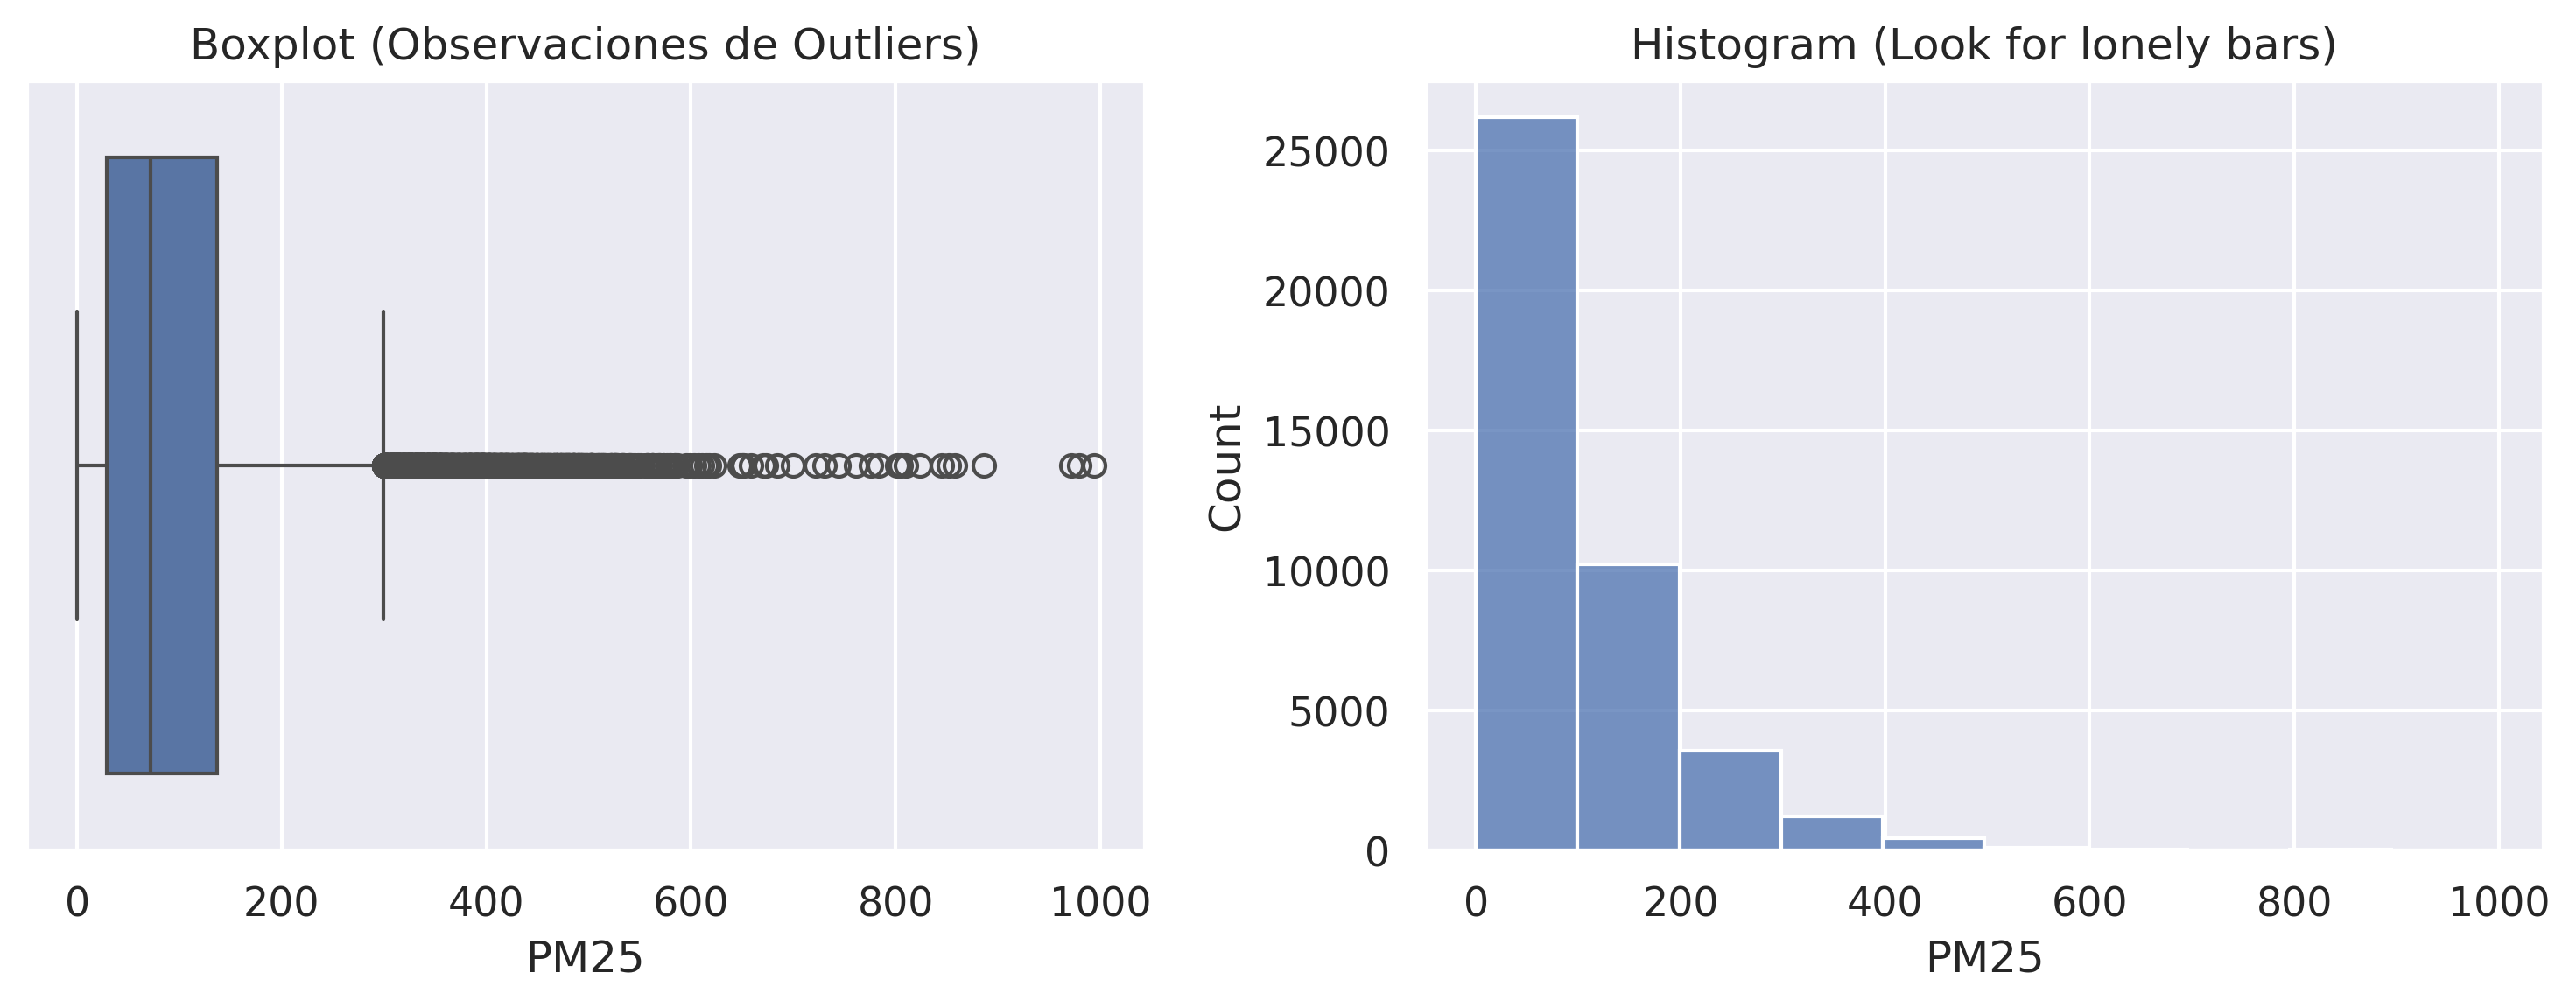

In [ ]:
# Para elegir el metodo de imputación, observamos los outliers del dataset
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["PM25"])
plt.title("Boxplot (Observaciones de Outliers)")

plt.subplot(1, 2, 2)
sns.histplot(df["PM25"], bins=10)
plt.title("Histogram (Look for lonely bars)")

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

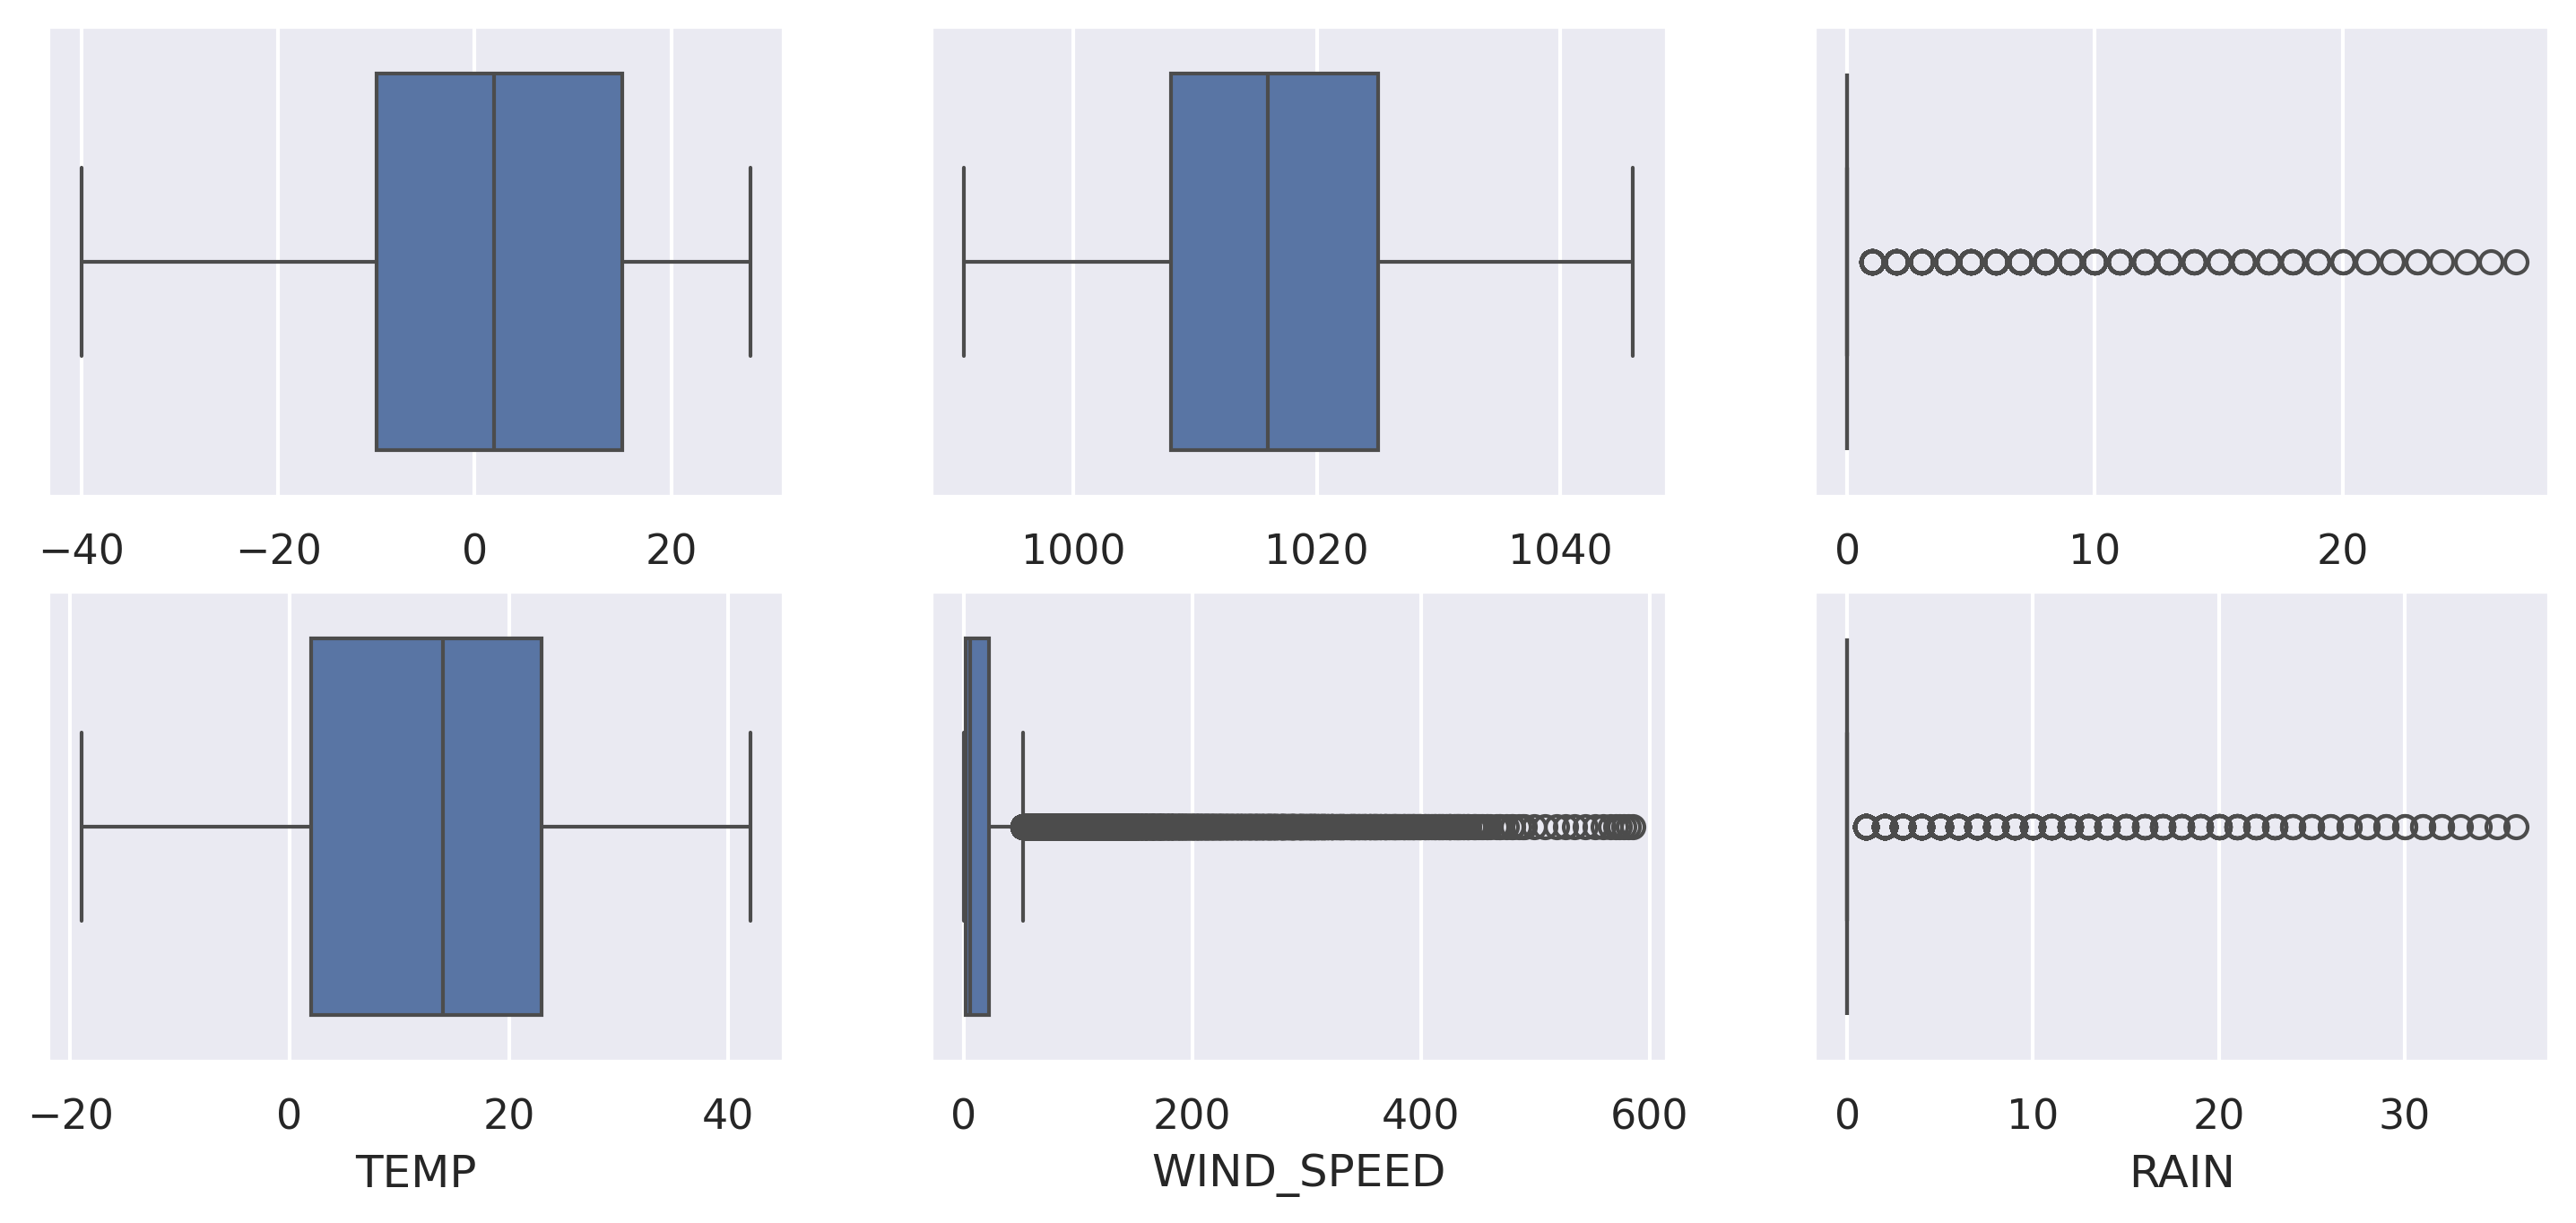

In [ ]:
# Analisis de outliers para cada variable

plt.rcParams["figure.dpi"] = 300

fig, axs = plt.subplots(2, 3, figsize=(12,5))

sns.boxplot(x="DEWPOINT", data=df, ax=axs[0,0])
sns.boxplot(x="TEMP", data=df, ax=axs[1,0])
sns.boxplot(x="PRESION", data=df, ax=axs[0,1])
sns.boxplot(x="WIND_SPEED", data=df, ax=axs[1,1])
sns.boxplot(x="SNOW", data=df, ax=axs[0,2])
sns.boxplot(x="RAIN", data=df, ax=axs[1,2])

plt.show

# SNOW y RAIN la mayoria de sus valores son 0, por eso la grafica de caja es una linea llena de outliers

In [ ]:
# Emmanuel: No me queda del todo claro que metodo de imputación elegir lol
# Entonces crearé diferetes dataset con diferentes metodos de imputación
df_imputed_mean = df_final.copy()
df_imputed_median = df_final.copy()

# imputaición con media (no aprecia tanto los outliers)
numeric_imputer_mean = SimpleImputer(strategy="mean")
df_imputed_mean["PM25_IMPUTED_MEAN"] = numeric_imputer_mean.fit_transform(df[["PM25"]])
# imputación con mediana (Maneja mejor los outliers)
numeric_imputer_median = SimpleImputer(strategy="median")
df_imputed_median["PM25_IMPUTED_MEDIAN"] = numeric_imputer_median.fit_transform(df[["PM25"]])

# Aqui nuestras columnas por modelar son:
# - PM25_IMPUTED_MEAN
# - PM25_IMPUTED_MEDIAN

print("Base de datos Imputada")
display(df_imputed_mean.sample(3))
display(df_imputed_median.sample(3))

# Habia otra forma mas rápida con Pandas, otra vez... (solo como observación, otra vez)
# Pero al parecer se recomienda usar la de scikit-learn
# df_encoded_by_pandas["PM25_IMPUTED_MEAN"] = df["PM25"].fillna(df["PM25"].mean())
# df_encoded_by_pandas["PM25_IMPUTED_MEDIAN"] = df["PM25"].fillna(df["PM25"].median())
# print("\nBase de datos Imputada (con pandas)")
# display(df_encoded_by_pandas.head(3))

Base de datos Imputada


,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,FECHA,FECHA_SIN_H,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv,PM25_IMPUTED_MEAN
27400,27401,2013,2,15,16,54.0,-13,2.0,1025.0,19.67,0,0,2013-02-15 16:00:00,2013-02-15,0.0,0.0,1.0,0.0,54.0
5276,5277,2010,8,8,20,141.0,22,26.0,1003.0,23.70,0,0,2010-08-08 20:00:00,2010-08-08,0.0,0.0,1.0,0.0,141.0
38875,38876,2014,6,8,19,25.0,15,22.0,1001.0,12.96,0,0,2014-06-08 19:00:00,2014-06-08,0.0,0.0,1.0,0.0,25.0


,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,FECHA,FECHA_SIN_H,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv,PM25_IMPUTED_MEDIAN
9030,9031,2011,1,12,6,49.0,-22,-13.0,1025.0,8.05,0,0,2011-01-12 06:00:00,2011-01-12,0.0,1.0,0.0,0.0,49.0
17934,17935,2012,1,18,6,401.0,-7,-5.0,1025.0,8.50,0,0,2012-01-18 06:00:00,2012-01-18,0.0,1.0,0.0,0.0,401.0
33111,33112,2013,10,11,15,46.0,0,23.0,1013.0,4.92,0,0,2013-10-11 15:00:00,2013-10-11,0.0,0.0,1.0,0.0,46.0


In [ ]:
# K-Nearest Neighbors (KNN), este tipo de imputación es bueno para datasets con variables agrupadas
# Que WIND_DIRECTION es la única variable categorica (factor)

df_numerico = df_final.select_dtypes(include=["number"])

knn_imputer = KNNImputer(n_neighbors=2)
imputed_data = knn_imputer.fit_transform(df_numerico)
df_imputed_KNN = pd.DataFrame(imputed_data, columns=df_numerico.columns)

# df_imputer_KNN es nuestro dataframe con metodo de imputación KNN
# en este la variable a modelas sigue siendo PM25

display(df_imputed_KNN.head(3))
display(df_imputed_KNN.isnull().sum())

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv
0,1.0,2010.0,1.0,1.0,0.0,138.5,-21.0,-11.0,1021.0,1.79,0.0,0.0,0.0,1.0,0.0,0.0
1,2.0,2010.0,1.0,1.0,1.0,138.5,-21.0,-12.0,1020.0,4.92,0.0,0.0,0.0,1.0,0.0,0.0
2,3.0,2010.0,1.0,1.0,2.0,138.5,-21.0,-11.0,1019.0,6.71,0.0,0.0,0.0,1.0,0.0,0.0


NO                   0
YEAR                 0
MONTH                0
DAY                  0
HOUR                 0
PM25                 0
DEWPOINT             0
TEMP                 0
PRESION              0
WIND_SPEED           0
SNOW                 0
RAIN                 0
WIND_DIRECTION_NE    0
WIND_DIRECTION_NW    0
WIND_DIRECTION_SE    0
WIND_DIRECTION_cv    0
dtype: int64

In [ ]:
# Iterative Imputation (MICE), supuestamente el mejor

mice_imputer = IterativeImputer(max_iter=10, random_state=0)
mice_imputer_data = mice_imputer.fit_transform(df_numerico)
df_imputed_mice = pd.DataFrame(mice_imputer_data, columns=df_numerico.columns)

# df_imputed_mice
# vairable a modelar imputada: PM25

display(df_imputed_mice.head(3))
display(df_imputed_mice.isnull().sum())

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv
0,1.0,2010.0,1.0,1.0,0.0,115.068227,-21.0,-11.0,1021.0,1.79,0.0,0.0,0.0,1.0,0.0,0.0
1,2.0,2010.0,1.0,1.0,1.0,123.984317,-21.0,-12.0,1020.0,4.92,0.0,0.0,0.0,1.0,0.0,0.0
2,3.0,2010.0,1.0,1.0,2.0,119.908046,-21.0,-11.0,1019.0,6.71,0.0,0.0,0.0,1.0,0.0,0.0


NO                   0
YEAR                 0
MONTH                0
DAY                  0
HOUR                 0
PM25                 0
DEWPOINT             0
TEMP                 0
PRESION              0
WIND_SPEED           0
SNOW                 0
RAIN                 0
WIND_DIRECTION_NE    0
WIND_DIRECTION_NW    0
WIND_DIRECTION_SE    0
WIND_DIRECTION_cv    0
dtype: int64

In [ ]:
# Para el escalado de variables, dado las propiedades de outliers de nuestro dataset
# Elegimos RobustScaler
# robust = RobustScaler()

# Preprocesamos los datos: Estadarización

# Para df_clean

cols_to_scale = ["DEWPOINT", "TEMP", "PRESION", "WIND_SPEED", "SNOW", "RAIN"]

ct = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), cols_to_scale)
    ],
    remainder='passthrough'
)

# Fit and transform the data
# Note: By default, this outputs a NumPy array or a Pandas DataFrame depending on your sklearn configuration
scaled_array = ct.fit_transform(df)
# Para df_imputed_mice




,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN
0,-21,-11.0,1021.0,1.79,0,0
1,-21,-12.0,1020.0,4.92,0,0
2,-21,-11.0,1019.0,6.71,0,0
3,-21,-14.0,1019.0,9.84,0,0
4,-20,-12.0,1018.0,12.97,0,0


In [ ]:
# Expotar .csv
df_clean.to_csv(PRSA_data_clean, sep='\t', encoding='utf-8', index=False, header=True)
df_imputed_mice.to_csv(PRSA_data_mice, sep='\t', encoding='utf-8', index=False, header=True)